### Семантическая сегментация

### Постановка задачи

Даны классы объектов, которые мы хотим сегментировать. Например, пусть мы хотим научиться сегментировать пять видов объектов:
1. человек;
2. сумка;
3. растительность;
4. дорога;
5. здания.

Вход нейросети — RGB картинка размера h*w*3 (так же, как в задаче классификации). Выход нейросети — двумерная карта сегментации размера h*w. Значение каждого пикселя карты сегментации — номер класса, которому принадлежит соответствующий пиксель исходной картинки.

На картинке могут быть объекты других классов, кроме тех, которые мы хотим сегментировать. Чтобы это учесть, добавим шестой класс сегментации: "фон". Ему будут соответствовать пиксели картинки, не принадлежащие ни одному из пяти заданных классов. В итоге наша задача превратится в задачу сегментации на 6 классов.

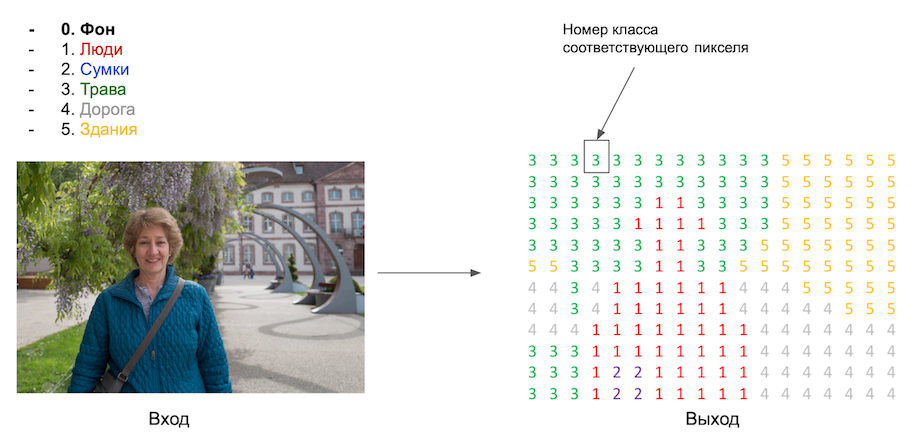

По сути, задача семантической сегментации — это задача классификации всех  пикселей картинки.

Вспомним, как решается задача классификации картинок: нейросеть для классификации в качестве ответа выдает не одно число — класс входящего объекта, — а вектор вероятностей принадлежности объекта к каждому из классов:

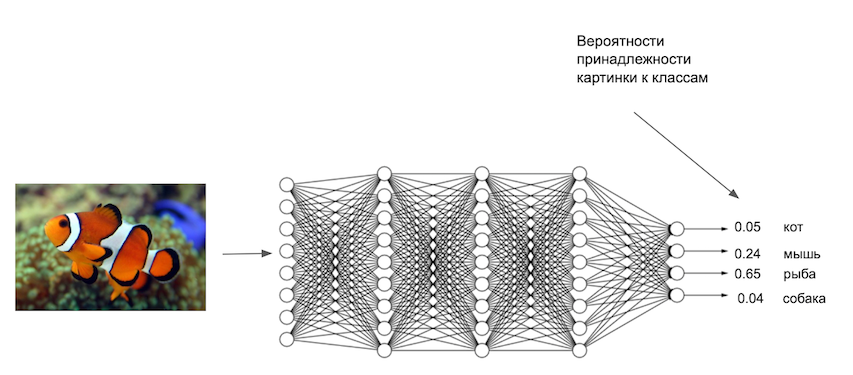

Поэтому логично было бы, чтобы нейросеть для сегментации для каждого пикселя выдавала тоже не одно число — класс этого пикселя, — а вектор вероятностей принадлежностей этого пикселя к каждому из заданных классов:

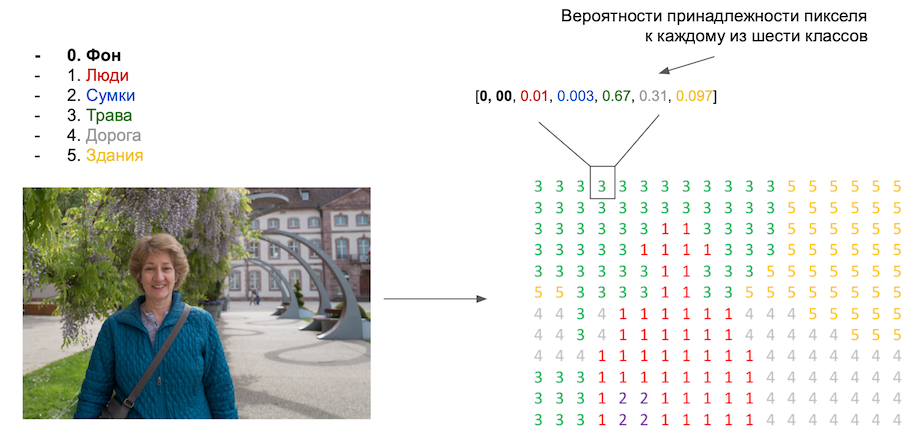

То есть, теперь желаемый выход нашей нейросети — это трехмерный тензор (матрица) размера h*w*c, где h, w — высота и ширина исходной картинки, c — количество классов сегментации (включая фон).

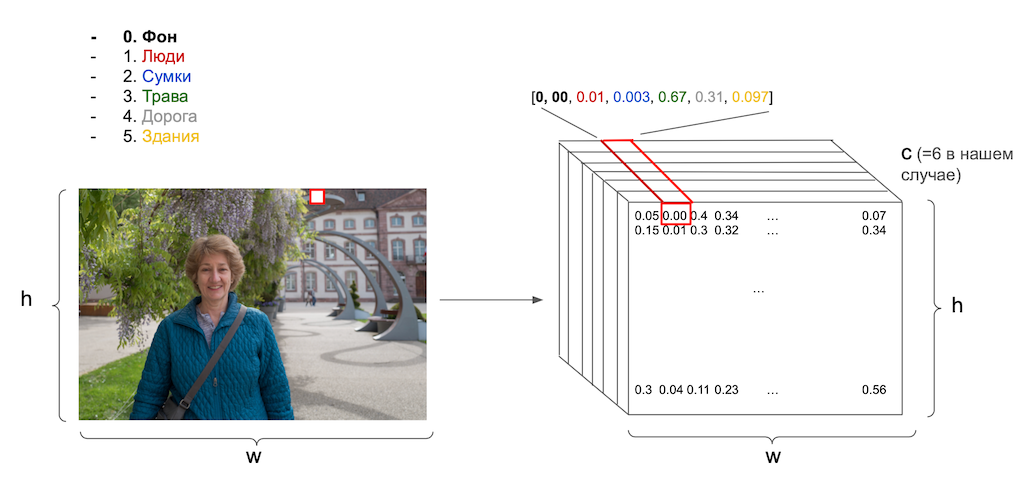

Итак, мы справились с постановкой задачи семантической сегментации. Поняли, что нейросеть будет принимать на вход и что выдавать на выход. Теперь перейдем к идеям того, как может быть устроена нейросеть для решения задачи семантической сегментации.


### Идеи решения задачи сегментации

#### №1: скользящее окно

Первая идея такая: смотрите, мы только что поняли, что сегментация — это, по сути, классификация каждого пикселя изображения. Так давайте и будем просто каждый пиксель классифицировать!

Пусть у нас есть картинка, которую мы хотим сегментировать. Будем проходиться по ней скользящим окном небольшого размера (например, семь на семь). В каждом положении скользящего окна будем подавать кусок картинки размера семь на семь, которую закрывает окно, на вход нейросети для классификации. Эта нейросеть будет одна и та же для всех положений скользящего окна. Задача этой нейросети — классифицировать центральный пиксель этого куска картинки на шесть классов. Понять, какому объекту из тех, что мы хотим сегментировать, этот пиксель принадлежит.

Например, на примере на слайде центральные пиксели первых двух патчей соответствуют траве, а  центральный пиксель третьего патча — человеку.

Таким образом, пройдясь скользящим окном по всей картинке, мы получим ответы нейросети для каждого пикселя картинки, чем, по сути, решим задачу сегментации этой картинки. Чтобы получать ответы также и для граничных пикселей картинки, можно добавить к изображению padding.

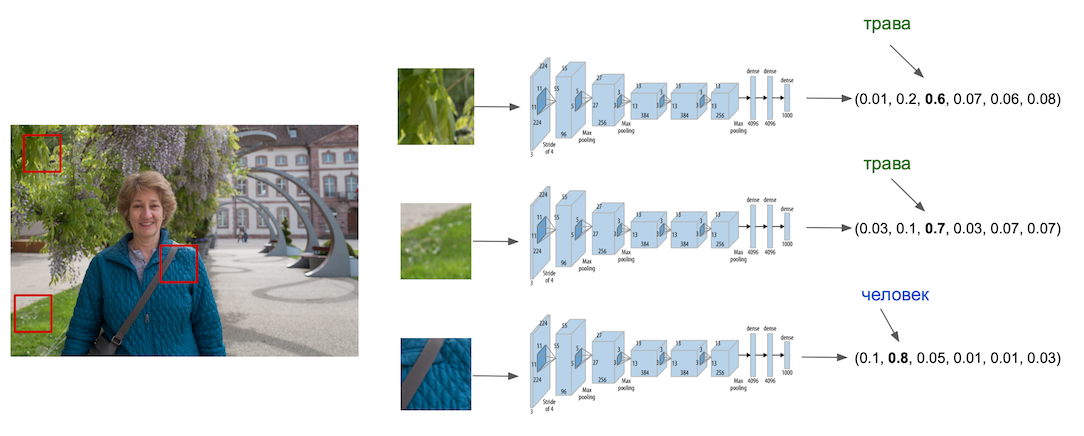

* Идея простая, но у нее есть довольно серьезные недостатки. 

Первый, самый очевидный — каждый патч картинки часто содержит очень малую часть объекта, по которой сложно, а иногда и практически невозможно понять, что на этом патче изображено. Посмотрим, например, на нижний патч на картинке выше. Согласитесь, даже для человека совсем не понятно, что это — часть куртки человека. Нейросеть на таких патчах тоже, конечно же, будет ошибаться.

Короче говоря, часто объекты имеют довольно большой размер, и чтобы эффективно классифицировать все пиксели этих объектов, скользящее окно должно быть довольно больших размеров. Настолько большим, чтобы, в идеале, захватывать весь объект целиком. Но в этом случае усугубляется вторая проблема такого алгоритма: он становится очень долгим.

Чтобы сегментировать одну картинку размера 32х32, нам нужно тысячу раз прогнать патч через сеть для классификации. Тысяча вызовов алгоритма — это довольно много, и работать это будет долго. А представьте, если у нас картинки больших размеров? А если при этом сделать размер патча больше, то сеть для классификации начнет работать еще дольше, и одна сегментация одной картинки станет занимать огромное количество времени и вычислительных ресурсов.

Выходит, подобный алгоритм неэффективен как с точки зрения качества сегментации, так и с точки зрения времени работы.

#### №2: fully-convolutional network

Идея такая: давайте сделаем сверточную нейросеть, у которой все карты активации будут иметь размер исходной картинки. И в последнем сверточном слое будет C карт активаций, где С — количество классов сегментации в нашей задаче. Полносвязных слоев у такой сети не будет. Такие сети, которые состоят только из сверточных слоев, называются fully-convolutional network.

Будем обучать эту нейросеть так, чтобы последние карты активации содержали ответ задачи сегментации на входящую картинку. Итоговая двумерная карта сегментации получается тем, что мы берем аргмаксимум по третьей размерности выхода сети.


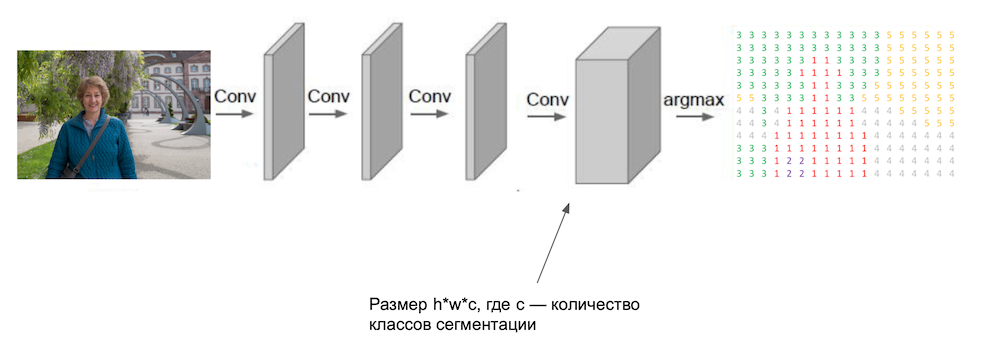

Эта идея будет работать, но и у нее есть существенный недостаток. Он снова связан с тем, что такая нейросеть будет работать очень долго. Если картинка, которую вы подаете на вход модели, большого размера, то и все карты активации на всех этапах работы сети будут такого же большого размера. А для вычисления таких больших карт активации требуется много вычислительных ресурсов.

Значит, **мы хотим как-то сократить количество вычислений, которые нейросеть делает в процессе сегментации. **


#### №3: convolutional network + upsampling

Третья идея такая: чтобы уменьшить количество вычислений, давайте все же будем уменьшать размеры карт активаций при движении к концу сети. Выход нейросети будет размера h’ x w’ x c, где h’ и w’ — размеры карт активацийпоследнего слоя, c — количество классов сегментации. По сути, нейросеть будет выдавать уменьшенную версию карты сегментации. Ну или карту сегментации для уменьшенной изначальной картинки.

После этого мы эту карту сегментации будем увеличивать до оригинального размера картинки. Увеличивать будем простым алгоритмом upsampling, по сути, просто растягивая полученную картинку по длине и ширине.

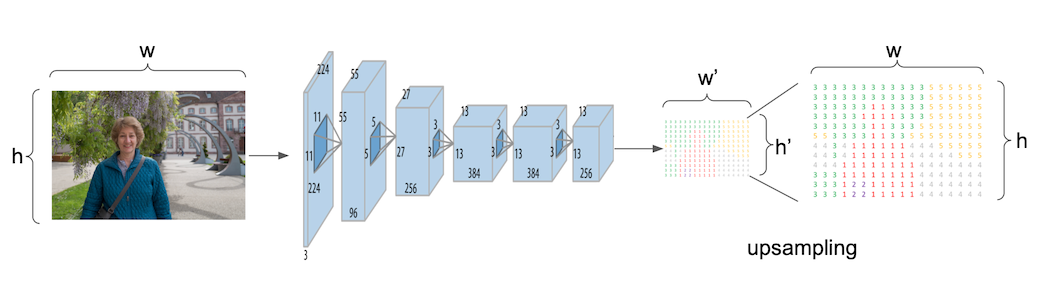

Пример upsampling (этот вариант называется nearest neighbors):

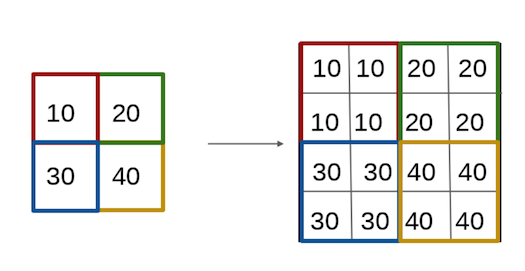

У этого алгоритма есть очевидный недостаток: точность его работы. Алгоритм предсказывает карту сегментации для уменьшенной версии исходной картинки, и от этого теряются детали, и сегментация получается очень неточной.

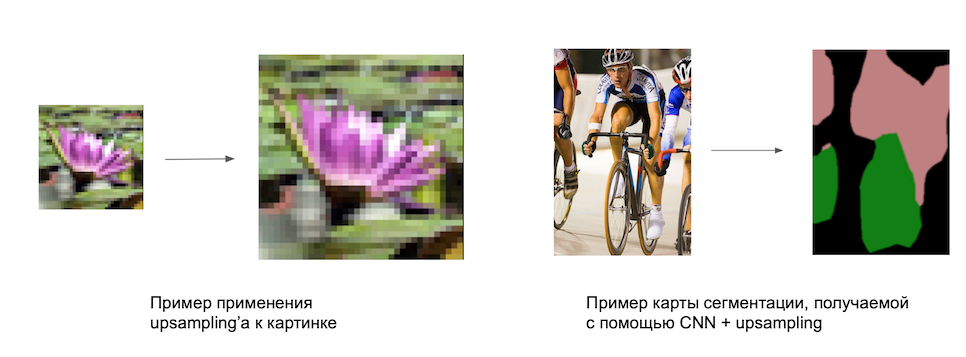

Однако этот алгоритм довольно долго использовался для решения задачи сегментации. И люди за время придумали, как улучшить точность итоговой карты сегментации с помощью специального алгоритма для постобработки результата. Он называется conditional random fields, сокращенно CRF. И он улучшал качество сегментации довольно сильно.

Вот пример того, какой могла получиться карта сегментации на выходе нейросети и после применения CRF:

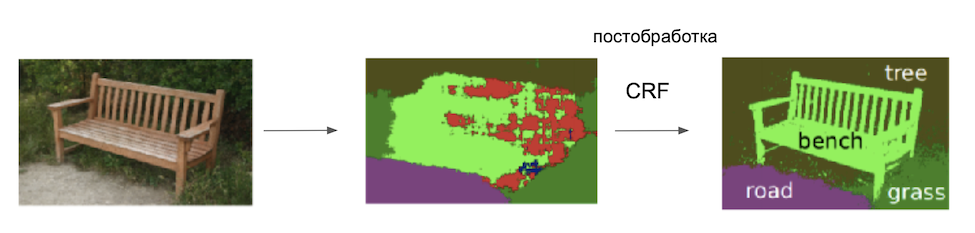

Давайте обратим внимание на две последние идеи (fully-convolutional network и CNN + upsampling). В идеале нам бы хотелось получить что-то среднее между ними: нейросеть, которая была бы способна выдавать хорошую карту сегментации того же размера, что изначальная картинка, но при этом у нее не было бы такое большое количество параметров, как у fully-convolutional network.

По сути, **мы хотели бы придумать более умную замену upsampling'у**. И сейчас мы поймем, как это сделать. Для этого изучим новый слой: transposed convolution.




### Transposed convolution

**Transposed convolution — обучаемая замена алгоритму upsampling**. Transposed convolution — слой, который увеличивает размеры карт активаций (а не уменьшает их размер, как обычный сверточный слой). Как понятно из названия, слой transposed convolution основан на свертках.

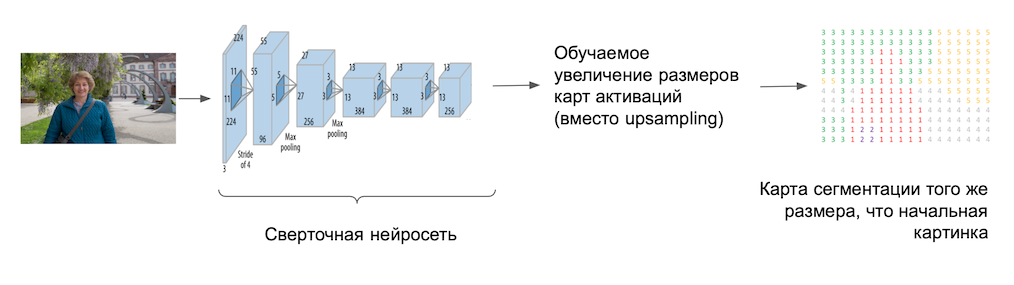

**Transposed convolution — это комбинация upsampling + convolution**

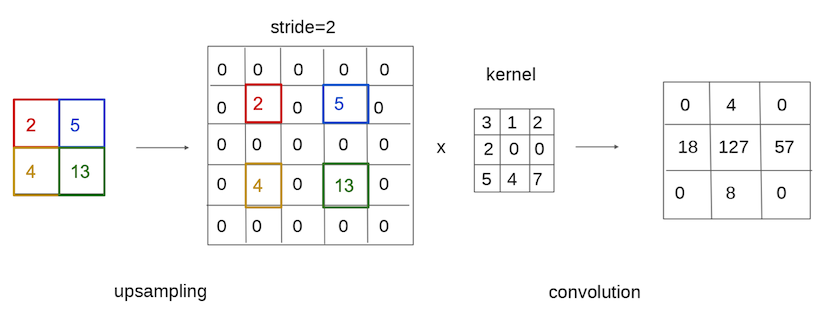

Бывают разные варианты upsampling, но для transposed convolution чаще всего используют bed of nails:

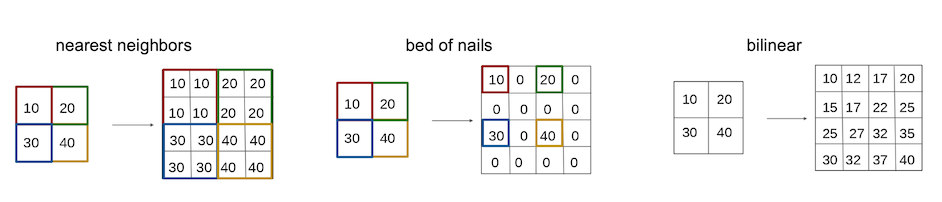

Применяя к изначальной карте активации разные виды upsampling'а с разными параметрами, можно получать разные виды слоев transposed convolution.

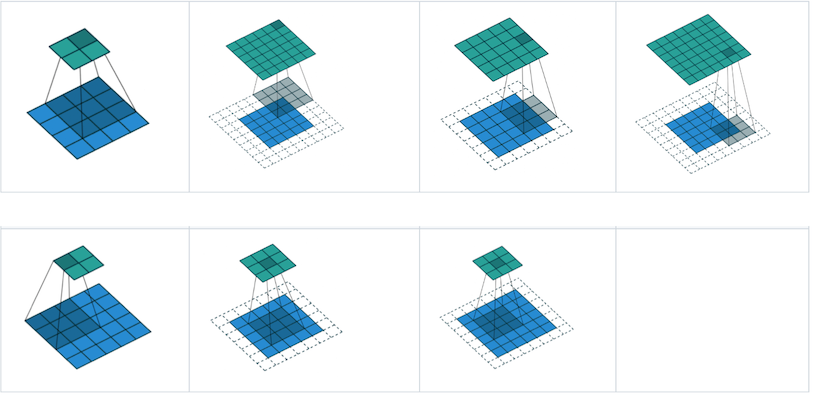

Обучаемыми параметрами слоя transposed convolution являются все веса всех фильтров. Upsampling не является обучаемым.

Слой transposed convolution также часто называют deconvolution. Строго это неправильно: операция transposed convolution не является обратной к операции convolution. Но в литературе часто можно встретить название deconvolution применительно к transposed convolution.

### SegNet

Таким образом, вместо простого upsampling в нейросети мы можем использовать слои transposed convolution (т.е. слои upsampling+conv). В итоге схему нейросети можно проиллюстрировать так:

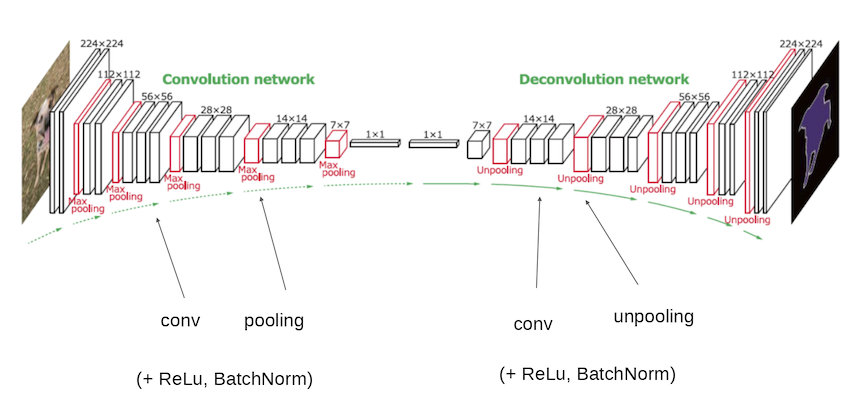

У такой нейросети можно условно выделить две части: encoder (левая часть, свертки) и decoder (правая часть, transposed convolution). Чаще всего encoder и decoder делают симметричными: каждый слой upsampling в декодере соответствует слою pooling в енкодере, а каждый слой conv в декодере — слою conv в енкодере.

Такая архитектура нейросети — классическая для решения задачи сегментации. Она называется SegNet.

### U-Net

U-Net — это нейросеть на основе SegNet со skip connection.

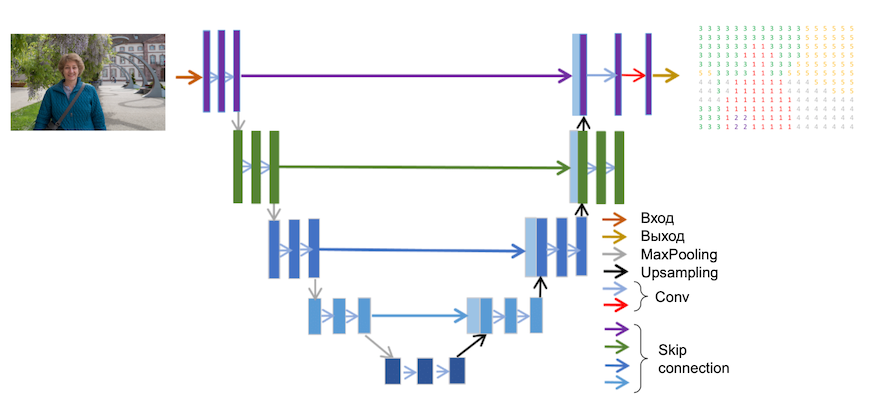

Skip connection проводится из выхода каждого блока левой части на вход соответствующему ему блоку правой части сети. Получается, блок правой части принимает на вход сумму карт активаций, пришедних из предыдушего слоя и из симметричного блока левой части сети.

Такая идея помогает нейросети создавать лучшие, более четкие карты сегментации. Смотрите, в нашей сети в середине есть узкое место: там, где карты активации сужаются и становятся малого размера. Такое место обычно называется bottleneck, то есть, бутылочное горлышко. И информация из изначальной картинки, когда она течет по сети, проходит через это узкое место, и часть информации там может теряться. Например, скорее всего, будет потеряна информация о мелких деталях исходного изображения. И когда затем слои транспонированной свертки правой части сети обратно восстанавливают изображение исходного размера, им может не хватать информации, полученной из последних слоев левой части, чтобы четко и качественно построить карту сегментации. Мелкие объекты, например, будут сегментированы плохо.

Применение такого skip connection помогает слоям правой части сети получить дополнительную информацию о том, как устроено исходное изображение. Это помогает получить более точную карту сегментации.

Такая нейросеть для сегментации со skip connection называется U-Net. U — потому что в такой иллюстрации сеть похожа на английскую букву U.

### Скачивание и распаковка данных

Мы будем решать задачу бинарной сегментации родинок и меланом. 

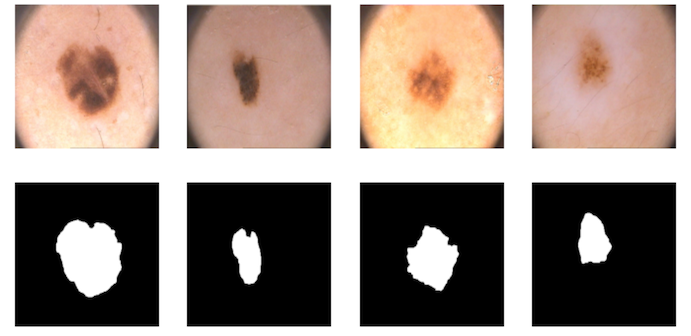

Скачиваем и распаковываем данные:


In [9]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [10]:
import kagglehub
path = kagglehub.dataset_download("spacesurfer/ph2-dataset")

100%|██████████| 203M/203M [00:07<00:00, 27.0MB/s] 

Extracting model files...


In [11]:
path

'C:\\Users\\Dmitry\\.cache\\kagglehub\\datasets\\spacesurfer\\ph2-dataset\\versions\\2'

In [2]:
### Загрузка данных и построение датасета
# Импортируем нужные модули:

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.nn import functional as F
from torchvision import transforms

Чтобы обучить нейросеть на этих данных, нам нужно их загрузить самостоятельно:

In [12]:
# библиотека для удобной работы с файлами на диске
import os
# библиотека для считывания картинок
from PIL import Image

# в эти массивы будем сохранять RGB картинки
# и их соответствующие карты сегментации
images = []
lesions = []

# название папки, в которой лежат данные
root = path

for dirname, _, files in os.walk(root):
    # Проверяем название текущей папки
    if dirname.endswith('_Dermoscopic_Image'):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif')):
                images.append(Image.open(os.path.join(dirname, f)))
    elif dirname.endswith('_lesion'):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif')):
                lesions.append(Image.open(os.path.join(dirname, f)))

In [13]:
os.walk(root)

<generator object walk at 0x000001FE9D48BE40>

In [14]:
images

[<PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x572>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x574>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x574>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x574>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=766x576>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=766x575>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x573>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x573>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x573>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x573>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x573>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=764x572>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=765x573>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=764x574>,
 <PIL.BmpImagePlugin.BmpImageFile image mode=RGB size=764x574>,
 <PIL.BmpImagePlugin.BmpImageFile image 

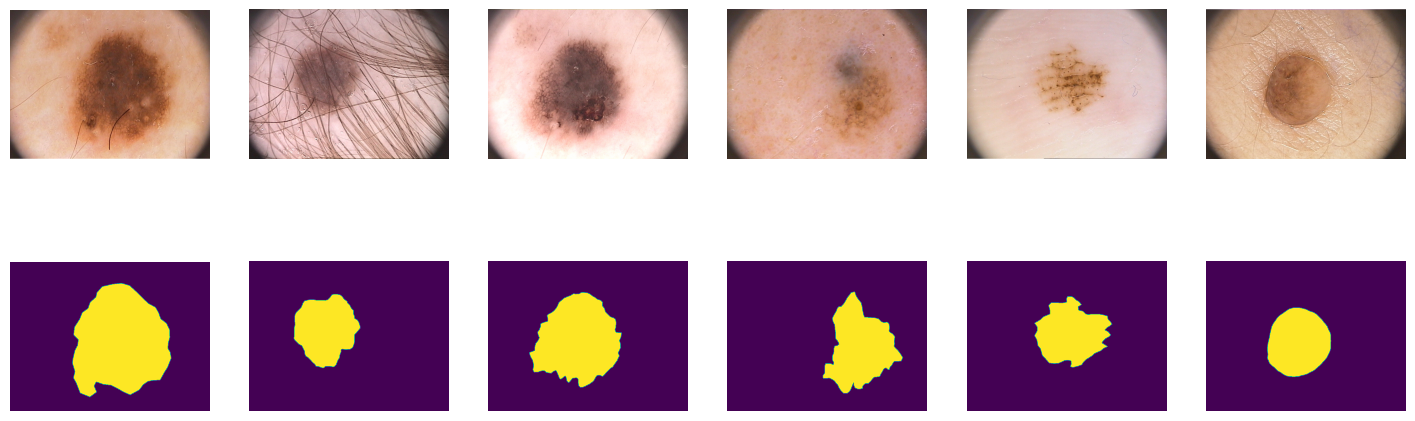

In [15]:
# Отрисуем несколько картинок и их карт сегментации, чтобы понять, с чем мы имеем дело:

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(np.array(images[i]))

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(np.array(lesions[i]))
plt.show();

In [16]:
# Чтобы работать с данными для сегментации, нужно создать кастомный класс датасет.

class PH2(Dataset):
    def __init__(self, images, lesions):

        self.images = images
        self.lesions = lesions

        self.img_transforms = transforms.Compose([
            transforms.Resize((256, 256)), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # значения пикселей картинки нормализуются
        ])

        self.seg_transforms = transforms.Compose([
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
        ])

    def __getitem__(self, index):
        '''
        этот метод должен по заданному номеру пары картинка-сегментация (index)
        возвращать эту пару. Этот метод обязательно нужно реализовывать во всех
        кастомных классах Dataset. Перед тем, как выдать на выходе
        пару картинка-сегментация, можно применить к картинкам любые преобразования.
        '''

        # находим по индексу нужные картинку и ее карту сегментации
        img = self.images[index]
        mask = self.lesions[index]

        # # применяем предобработку к RGB картинке
        img = self.img_transforms(img)
        # # применяем предобработку к маске сегментации
        mask = self.seg_transforms(mask)

        # возвращаем пару: картинка — ее маска сегментации
        return (img, mask)

    def __len__(self):
        '''
        этот метод должен возвращать количество пар картинка-сегментация в датасете
        '''
        return len(self.images)

In [17]:
data = PH2(images, lesions)

In [18]:
# Разделим наш датасет на три части: train, val и test:

train_size = 100
val_size = 50
test_size = 50

train_data, val_data, test_data = torch.utils.data.random_split(data, [train_size, val_size, test_size])

In [19]:
# Обернем три части датасета в dataloader'ы:

batch_size = 16
train_loader = DataLoader(train_data,
                     batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data,
                      batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data,
                     batch_size=batch_size, shuffle=False)

In [20]:
# Архитектура сети SegNet

class SegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder. conv + pooling
        self.enc_conv0 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(3,3), padding=1) # 256x256
        self.pool0 = nn.MaxPool2d(kernel_size=(2,2)) # 256 -> 128
        self.enc_conv1 = nn.Conv2d(in_channels=6, out_channels=9, kernel_size=(3,3), padding=1) # 128x128
        self.pool1 = nn.MaxPool2d(kernel_size=(2,2)) # 128 -> 64
        self.enc_conv2 = nn.Conv2d(in_channels=9, out_channels=12, kernel_size=(3,3), padding=1) # 64x64
        self.pool2 = nn.MaxPool2d(kernel_size=(2,2)) # 64 -> 32
        self.enc_conv3 = nn.Conv2d(in_channels=12, out_channels=15, kernel_size=(3,3), padding=1) # 32x32
        self.pool3 = nn.MaxPool2d(kernel_size=(2,2)) # 32 -> 16

        # bottleneck (середина, самая узнкая часть сети)
        self.bottleneck_conv = nn.Conv2d(in_channels=15, out_channels=15, kernel_size=(3,3), padding=1) # 16x16

        # decoder. upsample + conv
        self.upsample0 = nn.Upsample(scale_factor=2, mode='bilinear') # 16 -> 32
        self.dec_conv0 = nn.Conv2d(in_channels=15, out_channels=12, kernel_size=(3,3), padding=1) # 32x32
        self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear') # 32 -> 64
        self.dec_conv1 = nn.Conv2d(in_channels=12, out_channels=9, kernel_size=(3,3), padding=1) # 64x64
        self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear') # 64 -> 128
        self.dec_conv2 = nn.Conv2d(in_channels=9, out_channels=6, kernel_size=(3,3), padding=1) # 128x128
        self.upsample3 = nn.Upsample(scale_factor=2, mode='bilinear') # 128 -> 256
        self.dec_conv3 = nn.Conv2d(in_channels=6, out_channels=1, kernel_size=(3,3), padding=1) # 256x256

    def forward(self, x):
        # encoder
        e0 = self.pool0(F.relu(self.enc_conv0(x)))
        e1 = self.pool1(F.relu(self.enc_conv1(e0)))
        e2 = self.pool2(F.relu(self.enc_conv2(e1)))
        e3 = self.pool3(F.relu(self.enc_conv3(e2)))

        # bottleneck
        b = self.bottleneck_conv(e3)

        # decoder
        d0 = F.relu(self.dec_conv0(self.upsample0(b)))
        d1 = F.relu(self.dec_conv1(self.upsample1(d0)))
        d2 = F.relu(self.dec_conv2(self.upsample2(d1)))
        # сигмоидная функция активации, потому что у нас задача
        # бинарной сегментации
        # в случае многоклассовой сегментации был бы softmax
        d3 = F.sigmoid(self.dec_conv3(self.upsample3(d2)))
        return d3

### Обучение сети

In [21]:
device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

'cpu'

In [22]:
# Функция обучения сети:

from IPython.display import clear_output

def train(model, opt, loss_fn, epochs, train_loader, val_loader):

    for epoch in range(epochs):
        # печатаем номер текущей эпохи
        print('* Epoch %d/%d' % (epoch+1, epochs))

        # 1. Обучаем сеть на картинках из train_loader
        model.train()  # train mode

        avg_train_loss = 0
        for i, (X_batch, Y_batch) in enumerate(train_loader):
            # переносим батч на GPU
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            # получаем ответы сети на батч
            Y_pred = model(X_batch)

            # считаем лосс, делаем шаг оптимизации сети
            loss = loss_fn(Y_pred, Y_batch)
            loss.backward()
            opt.step()
            opt.zero_grad()

            avg_train_loss += loss / len(train_loader)

        # выводим средний лосс на тренировочной выборке за эпоху
        print('avg train loss: %f' % avg_train_loss)

        # 2. Тестируем сеть на картинках из val_loader
        model.eval()

        avg_val_loss = 0
        for i, (X_batch, Y_batch) in enumerate(val_loader):
            # переносим батч на GPU
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            # получаем ответы сети на батч
            Y_pred = model(X_batch)
            # считаем лосс на батче
            loss = loss_fn(Y_pred, Y_batch)

            avg_val_loss += loss / len(val_loader)

        # выводим средний лосс на валидационных данных
        print('avg val loss: %f' % avg_val_loss)


        # 3. Визуализируем ответы сети на шести картинках из валидационных данных

        # получаем один батч из data_val
        X_val, Y_val = next(iter(val_loader))
        # получаем ответ сети на картинки из батча
        Y_pred = model(X_val.to(device))
        Y_pred = Y_pred.detach().cpu().numpy()

        # удаляем предыдущую визуализацию
        clear_output(wait=True)

        # визуализируем исходные картинки, верный ответ и ответ нашей модели
        _, axes = plt.subplots(3, 6, figsize=(6*4, 3*4))
        for k in range(6):
            # отрисовываем 6 картинок, поданных на вход сети
            # картинки нормализованы, поэтому могут выглядеть непривычно
            axes[0][k].imshow(np.rollaxis(X_val[k].numpy(), 0, 3), cmap='gray', aspect='auto')
            axes[0][k].title.set_text('Input')

            # отрисовываем правильные маски сегментации для шести картинок выше
            axes[1][k].imshow(Y_val[k].numpy()[0], cmap='gray', aspect='auto')
            axes[1][k].title.set_text('Real Map')

            # отрисовываем ответы сети для каждого из четырех классов сегментации в отдельности
            axes[2][k].imshow(Y_pred[k][0], cmap='gray', aspect='auto')
            axes[2][k].title.set_text('Output')
        plt.suptitle('%d / %d - val loss: %f' % (epoch+1, epochs, avg_val_loss))
        plt.show()

Определяем модель, функцию потерь, оптимизатор, и запускаем обучение сети:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


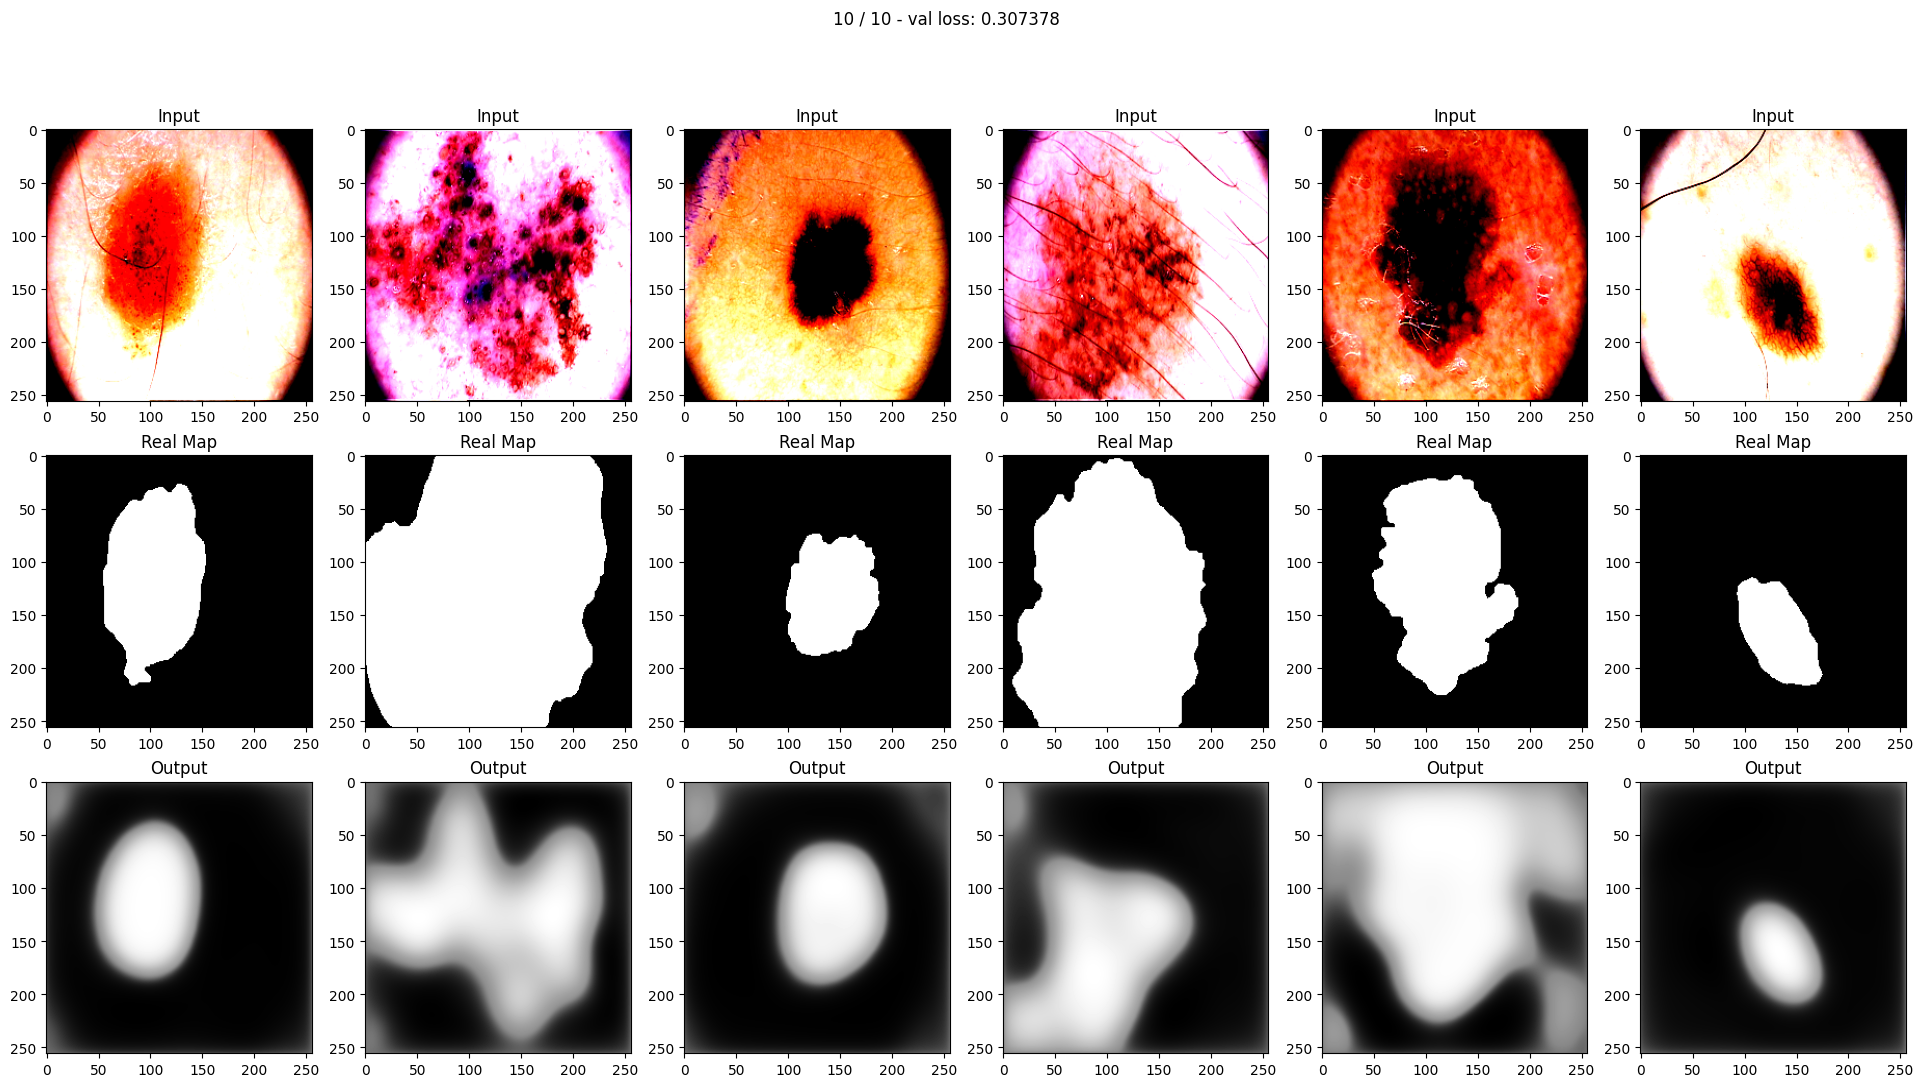

In [23]:
model = SegNet().to(device)
# бинарная кросс-энтропия
loss = nn.BCELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
train(model, opt, loss, 10, train_loader, val_loader)

In [24]:
# сохранить веса модели
torch.save(model.state_dict(), "segnet_ph2.pth")
print("Модель сохранена: segnet_ph2.pth")

Модель сохранена: segnet_ph2.pth


In [25]:
model = SegNet().to(device)
model.load_state_dict(torch.load('segnet_ph2.pth', map_location=device))
model.eval()  

SegNet(
  (enc_conv0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (enc_conv1): Conv2d(6, 9, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Conv2d(9, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (enc_conv3): Conv2d(12, 15, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (bottleneck_conv): Conv2d(15, 15, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upsample0): Upsample(scale_factor=2.0, mode='bilinear')
  (dec_conv0): Conv2d(15, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upsample1): Upsample(scale_factor=2.0, mode='bilinear')
  (

In [26]:
from PIL import Image
import torch
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

def predict_segmentation(model, image_path, device='cpu'):
    model.eval()

    # Трансформации, как при обучении
    img_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # Загружаем картинку
    img = Image.open(image_path).convert('RGB')
    img_t = img_transform(img).unsqueeze(0).to(device)  # добавляем batch dim

    # Предсказание
    with torch.no_grad():
        pred = model(img_t)

    # Получаем 2D-маску из тензора (0–1)
    mask = pred[0, 0].cpu().numpy()

    # Бинаризуем (например, порог 0.5)
    mask_bin = (mask > 0.5).astype(np.uint8)

    # Показываем результат
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title('Input image')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask_bin, cmap='gray')
    plt.title('Predicted mask')
    plt.axis('off')
    plt.show()

    return mask_bin


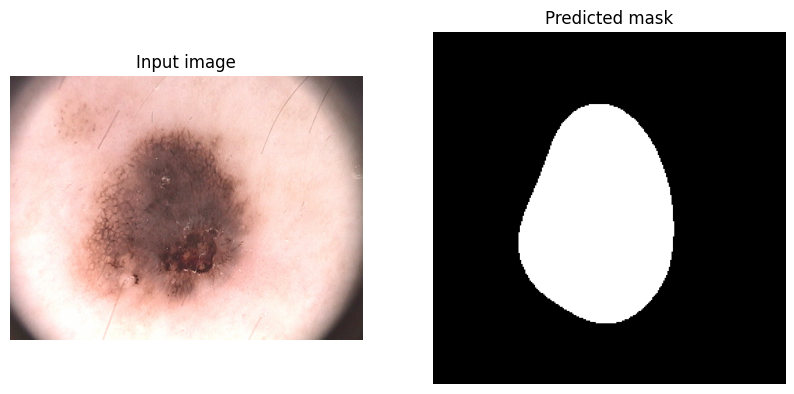

In [28]:
mask = predict_segmentation(model, 'segment_example.bmp', device)

### Задача 5
1. Выбрать датасет изображений для обучения модели для сегментации 
2. Реализовать модель CNN и обучить ее на вашем датасете.
3. Подготовить метрики качетсва обученной модели.
4. Подготовить отчет с примерами применения вашей модели для сегментации или детекции. К отчету приложить обученную модель

* Ресурс с датасетами для обучения https://www.kaggle.com/metavision/datasets